# Example using an ROI

In [1]:
%matplotlib widget

### Importing utils

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
from matplotlib import transforms
from pyiconeus.io.base import open_path
from pyiconeus.models.Scan import Scan
from pyiconeus.models.Bps import Bps
from pyiconeus.models.Roi import Roi, RoiElements
from pyiconeus.utils.utils import scaleMatrix, translationMatrix
from ipywidgets import *

# Scan loading and setup

### 1) Loading the scan

In [3]:
scan: Scan = open_path("../tests/data/4Dscan_11_StimVIS16__60_30_60_8_fus3D.source_v2.scan")
voxels = scan.voxels
voxels.shape

(103, 16, 92, 325, 1, 1)

### 2) Normalising the values

In [4]:
maxvoxels = np.max(voxels)
minvoxels = np.min(voxels)
print(maxvoxels)
print(minvoxels)
norm_voxels = voxels

155.89466887408625
0.0


### 3) Arranging the array for display purpose

In [5]:
# norm_voxels = (voxels - minvoxels) / (maxvoxels - minvoxels)

### 4) Rotate the image using scipy (optional)

In [6]:
# norm_voxels = np.transpose(norm_voxels, axes=(2, 1, 0, 3, 4, 5))


# Bps loading and adding to the scan

In [7]:
bps: Bps = open_path("../tests/data/4Dscan_11_StimVIS16__60_30_60_8_fus3D.source_v2.bps")
bps.data

array([[ 4.84566589e-06,  3.79931854e-03, -1.91796494e-04,
        -8.60974620e-03],
       [-3.68395440e-03, -7.86178619e-05,  4.65749483e-05,
        -1.06963227e-03],
       [-2.30356275e-05,  1.95067317e-04,  3.69308293e-03,
        -4.50932597e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [8]:
scan.bps = bps

# Utils function to display the ROI volume

In [9]:
def _to_row_major(arr, n_cols=3):
    """
    Normalize to shape (n, n_cols) regardless of whether the source array was
    stored as (n_cols, n) or (n, n_cols). Diagnosis: roi.vertices / roi.faces
    from pyiconeus turned out to be (n, 3) already (n rows, one per
    vertex/face), NOT (3, n) as originally assumed -- so a blind `.T` was
    transposing correctly-shaped data into the wrong shape, causing vertex
    indices to be looked up on the coordinate axis (size 3) instead of the
    vertex axis (size n), hence "index 4 is out of bounds for axis 0 with
    size 3".
    """
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")
    if arr.shape[0] == n_cols and arr.shape[1] != n_cols:
        return arr.T
    return arr


In [10]:
def volume(roi: RoiElements):
    """
    Mesh volume via the divergence theorem: sum the signed volume of the
    tetrahedron formed by each face and the origin.
    """
    v = _to_row_major(roi.vertices)
    f = _to_row_major(roi.faces).astype(int)
    v0, v1, v2 = v[f[:, 0]], v[f[:, 1]], v[f[:, 2]]
    signed_vols = np.einsum('ij,ij->i', v0, np.cross(v1, v2))
    return abs(signed_vols.sum()) / 6.0


In [11]:
def slice_contour(roi: RoiElements, coord, axis=1):
        """
        Intersect the mesh with the plane {axis-th coordinate == coord} and
        return the convex hull of the intersection, as an (k, 2) array of
        points in the two remaining coordinates (in hull order, ready to
        pass straight to matplotlib's Polygon). Returns None if the plane
        misses the mesh (or touches it in fewer than 3 distinct points).

        Note: taking the convex hull is an approximation -- if your ROI is
        non-convex or has a concave/donut-shaped cross-section, this will
        "fill in" the concavities.
        """
        v = _to_row_major(roi.vertices)
        f = _to_row_major(roi.faces).astype(int)
        pts = []

        for tri in f:
            tri_v = v[tri]
            c = tri_v[:, axis]
            for i in range(3):
                j = (i + 1) % 3
                c0, c1 = c[i], c[j]
                if (c0 - coord) * (c1 - coord) < 0:
                    
                    t = (coord - c0) / (c1 - c0)
                    pts.append(tri_v[i] + t * (tri_v[j] - tri_v[i]))
                elif c0 == coord:
                    pts.append(tri_v[i])

        if len(pts) < 3:
            return None

        pts = np.array(pts)
        other_axes = [a for a in range(3) if a != axis]
        pts_2d = pts[:, other_axes]
        pts_2d = np.unique(np.round(pts_2d, 6), axis=0)

        if len(pts_2d) < 3:
            return None

        try:
            hull = ConvexHull(pts_2d)
        except Exception:
            return None

        return pts_2d[hull.vertices]

In [12]:
class ROISliceViewer:
    def __init__(self, volume_img, roi: RoiElements, axis=1, cmap='gray'):
        self.volume_img = volume_img
        self.roi = roi
        self.axis = axis
        self.slice_idx = volume_img.shape[axis] // 2
 
        self.fig, self.ax = plt.subplots()
        plt.subplots_adjust(bottom=0.2)
 
        self.im = self.ax.imshow(self._get_slice(self.slice_idx), cmap=cmap)
        self.ax.set_title(f"ROI volume: {volume(roi):.2f}")
 
        self.poly = None
        self._update_roi(self.slice_idx)
 
        from matplotlib.widgets import Slider
        ax_slider = plt.axes([0.2, 0.06, 0.6, 0.03])
        self.slider = Slider(
            ax_slider, 'Slice', 0, volume_img.shape[axis] - 1,
            valinit=self.slice_idx, valstep=1
        )
        self.slider.on_changed(self._on_slide)
 
    def _get_slice(self, idx):
        return np.take(self.volume_img, idx, axis=self.axis)
 
    def _on_slide(self, val):
        idx = int(val)
        self.im.set_data(self._get_slice(idx))
        self._update_roi(idx)
        self.fig.canvas.draw_idle()
 
    def _update_roi(self, idx):
        if self.poly is not None:
            self.poly.remove()
            self.poly = None
 
        contour = slice_contour(self.roi, idx, axis=self.axis)
        if contour is not None:
            contour_xy = contour[:, ::-1]
            color = (1, 0, 0, 0.4)
            self.poly = Polygon(
                contour_xy, closed=True,
                facecolor=color,
                edgecolor=color,
                linewidth=1.5,
            )
            self.ax.add_patch(self.poly)
 
    def show(self):
        plt.show()


In [13]:
def apply_transform(vertices, matrix):
    """
    vertices: (n, 3) array, one row per vertex
    matrix:   (4, 4) homogeneous affine, (3, 3) rotation/scale only, or (3, 4) affine
    returns:  (n, 3) transformed vertices
    """
    vertices = np.asarray(vertices, dtype=float)
    matrix = np.asarray(matrix, dtype=float)
    n = vertices.shape[0]
 
    if matrix.shape == (4, 4):
        homo = np.hstack([vertices, np.ones((n, 1))])   # (n, 4)
        transformed = homo @ matrix.T                     # (n, 4)
        return transformed[:, :3] / transformed[:, 3:4]
    else:
        raise ValueError(f"Unexpected transform shape: {matrix.shape}")


# Roi loading

In [15]:
roi: Roi = open_path("../tests/data/roi_for_4DStacked.bri")

In [16]:
probe2Lab = scan.get_ProbeToLab()[0]
voxel2Probe = scan.get_VoxelToProbe()
Brain2Voxel = np.linalg.inv(voxel2Probe) @ np.linalg.inv(probe2Lab) @ scan.bps.data

In [17]:
def describe(name, M):
    # rough "scale" of a transform matrix: the norm of its linear part
    scale = np.linalg.norm(M) * np.linalg.norm(np.linalg.inv(M))
    print(f"{name}: scale~{scale:.6g}")
    print(M)
    print()

describe("bps.data", scan.bps.data)
describe("probe2Lab", probe2Lab)
describe("voxel2Probe", voxel2Probe)
describe("BrainToVoxel", Brain2Voxel)

bps.data: scale~465.399
[[ 4.84566589e-06  3.79931854e-03 -1.91796494e-04 -8.60974620e-03]
 [-3.68395440e-03 -7.86178619e-05  4.65749483e-05 -1.06963227e-03]
 [-2.30356275e-05  1.95067317e-04  3.69308293e-03 -4.50932597e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

probe2Lab: scale~4.00159
[[ 1.74500083e-03 -9.99998477e-01  0.00000000e+00 -1.00902500e-02]
 [ 9.99998477e-01  1.74500083e-03  0.00000000e+00 -8.77500000e-04]
 [-0.00000000e+00 -0.00000000e+00  1.00000000e+00 -3.85940000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

voxel2Probe: scale~13755.9
[[ 1.10000000e-04  0.00000000e+00  0.00000000e+00 -5.72000000e-03]
 [ 0.00000000e+00  5.25333333e-04  0.00000000e+00 -4.46533333e-03]
 [ 0.00000000e+00  0.00000000e+00 -9.85600000e-05 -9.01440000e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]

BrainToVoxel: scale~227.842
[[-3.34903667e+01 -6.54435711e-01  4.20365385e-01  5.02768318e+01]
 [-2.14609683e-02 -

# Interactive display

interactive(children=(IntSlider(value=162, description='nTime', max=324), IntSlider(value=8, description='pose…

<function __main__.update(nTime, pose, roiValue)>

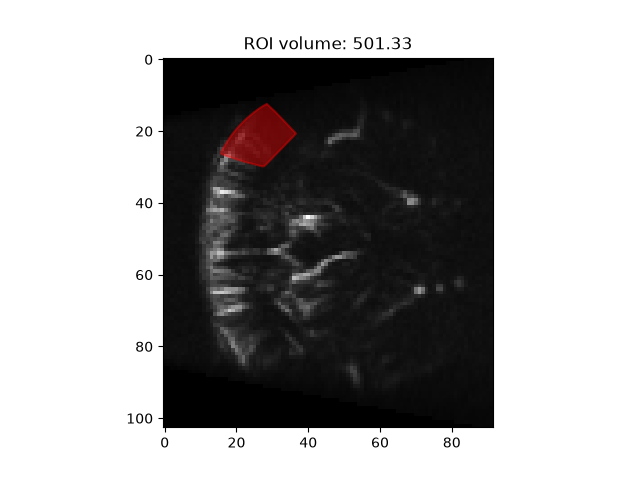

In [18]:
fig, ax = plt.subplots()
im = ax.imshow(norm_voxels[:, int(scan.sizeY / 2), :, int(scan.nTime / 2), 0, 0], cmap='gray')
poly_artist = {"poly": None}
transformed_cache = {}

def update(nTime, pose, roiValue):
    img_slice = norm_voxels[:, pose, :, nTime, 0, 0]
    im.set_data(img_slice)
    im.set_extent([-0.5, img_slice.shape[1] - 0.5, img_slice.shape[0] - 0.5, -0.5])
    
 
    if poly_artist["poly"] is not None:
        poly_artist["poly"].remove()
        poly_artist["poly"] = None

    selectedRoi = roi.list[roiValue]
    if roiValue not in transformed_cache:
        transformed_cache[roiValue] = apply_transform(selectedRoi.vertices, Brain2Voxel)
    selectedRoi.vertices = transformed_cache[roiValue]
    title = ax.set_title(f"ROI volume: {volume(selectedRoi):.2f}")

    contour = slice_contour(selectedRoi, pose, axis=1)
    if contour is not None:
        color = (1, 0, 0, 0.4)
        contour_xy = contour[:, ::-1]
        poly_artist["poly"] = Polygon(
            contour_xy, closed=True,
            facecolor=color, edgecolor=color, linewidth=1.5,
        )
        ax.add_patch(poly_artist["poly"])
    base = plt.gca().transData
    rot = transforms.Affine2D().rotate_deg(90)
    ax.set_transform(rot + base)
    fig.canvas.draw_idle()

 
interact(
    update,
    nTime=widgets.IntSlider(value=int(scan.nTime / 2), min=0, max=scan.nTime - 1, step=1),
    pose=widgets.IntSlider(value=int(scan.sizeY / 2), min=0, max=scan.sizeY - 1, step=1),
    roiValue=widgets.Dropdown(
        options = [(roi.list[i].name, i) for i in range(len(roi.list))],
        value = 0,
        description = "ROI: ",
    )
)
